# **Analisis variables - Adultos vs Kids**

Este análisis contiene datos actualizados respecto al análisis presentado en la memoria y la presentación, por lo cuál hay algunas diferencias ligeras en las conclusiones. En algunos casos mencionamos también las conclusiones sacadas en el análisis anterior, ya que proporcionan información adicional relevante.

# Bibliotecas

In [ ]:
#Carga de datos
import pandas as pd
import numpy as np
import json
from comun.Server_PD import download_dataframe_minio

from collections import Counter
import re

import seaborn as sns
import matplotlib.pyplot as plt
import isodate

import comun.analisisutils as utils

c:\Users\Usuario\Documents\U SEGUNDO AÑO\SEGUNDO CUATRI\PD1\c2526-R1\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


# Carga de datos

In [ ]:
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260307",claves=claves,file_format="parquet")
df.tail()

,ID,Titulo,Descripcion,Visualizaciones,Tags,Duracion,Fecha_publicacion,Titulo_canal,Subtitulos,Generos,Subgeneros,Made for kids,Rango_edad
24138,LR4a1ISdAA4,Asterisk,Provided to YouTube by 'J Storm Inc.'\n\nAster...,356422,"嵐, ARASHI, THE, DIGITALIAN, Asterisk",PT4M35S,2020-02-06 10:12:04+00:00,ARASHI - Topic,None,Music,"Music, Music of Asia, Pop music",False,9-12
24139,WoXIdAgVsSc,Look What I Made By Boiling Seashells In Water...,Look What I Made By Boiling Seashells In Water...,219816,,PT32S,2024-09-13 18:00:15+00:00,SULTANIN OYUNCAK ATÖLYESİ,None,Howto & Style,"Food, Hobby, Lifestyle (sociology)",False,9-12
24140,l1f2gl6ix0w,KPOP Demon Hunters | Saja Boys - YOUR IDOL [Fe...,💗Escucha esta canción en plataformas digitales...,7759536,"kpop demon hunters, las guerreras kpop, huntri...",PT2M17S,2025-07-08 20:00:06+00:00,Hitomi Flor,None,Music,"Music, Music of Asia, Music of Latin America, ...",False,9-12
24141,3NqgocCQU1w,Minecraft Food vs Nick DiGiovanni,SUBSCRIBE!!!\n\nWanna be in a vid??\nJoin http...,468715,"karl jacobs, minecraft, minecraftshorts",PT40S,2025-08-15 16:00:10+00:00,Karl,None,Gaming,"Food, Role-playing video game, Video game culture",False,9-12
24142,DAXbzfzTaeQ,Instant Regret Pets | Funny Pet Video Compilation,Instant regret! Sometimes animals let their cu...,102499,"the pet collective, pet collective, the pet co...",PT1M42S,2017-12-20 14:00:03+00:00,The Pet Collective,None,Pets & Animals,"Humour, Lifestyle (sociology), Pet",False,9-12


# Transformamos la columna "Duracion"

In [3]:

df['Duracion'] = df['Duracion'].apply(utils.iso_a_minutos)

# Dividimos los datos en "Adult" y "Kids"

In [4]:
df_Adult, df_Kids = utils.division_edad(df)

print(f'Size of Kids: {len(df_Kids)}')
print(f'Size of Adults: {len(df_Adult)}')


Size of Kids: 12632
Size of Adults: 11511


# Análisis no textual

## Duración

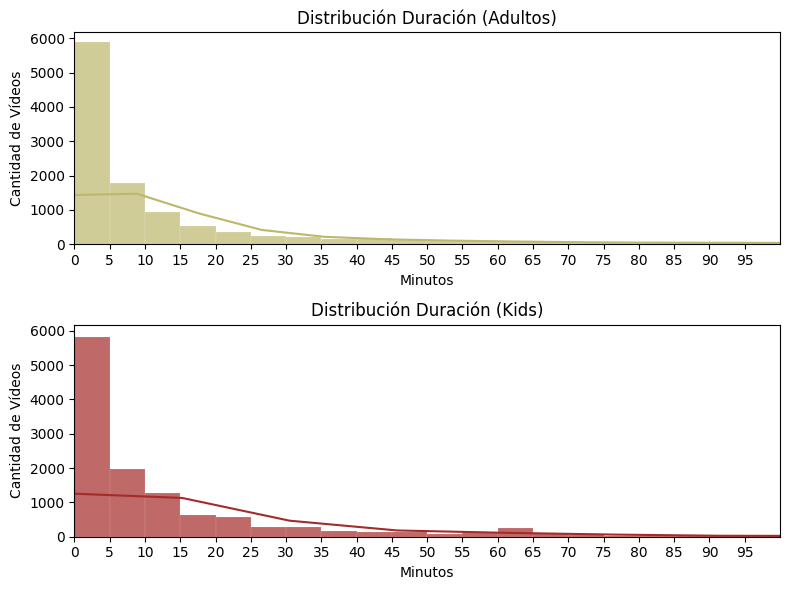

In [5]:

# Configuración
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharey=True)

utils.graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0], 'darkkhaki')
utils.graficar_histograma_duracion(df_Kids, 'Distribución Duración (Kids)', ax[1], 'brown')

plt.tight_layout()
plt.show()

La distribución en ambos casos está extremadamente concentrada en duraciones muy cortas (generalmente entre 0 y 10 minutos). Se puede observar que apenas hay videos de más de 15 minutos.
Las diferencias entre los grupos no son casi notables.

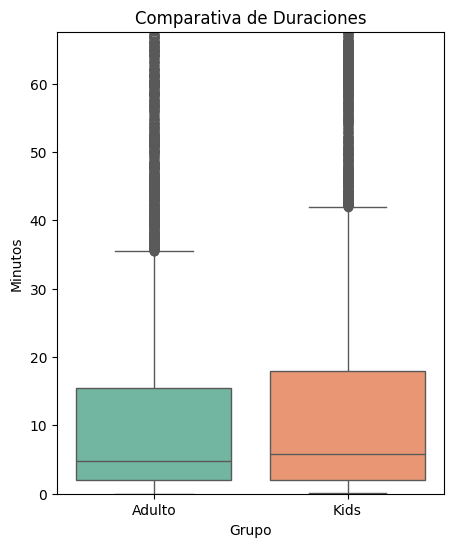

In [6]:
df_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

Como se puede observar la mediana es prácticamente igual para adultos que para niños. Esto sugiere que hay un tiempo ideal para mantener la atención antes de que el usuario pase al siguiente vídeo, independientemente de su edad. Se puede estimar que este valor está entre 5 y 8 minutos.

Se puede apreciar que la caja del grupo "kids" es ligeramente más amplia. Lo que significa que hay más variedad en las duraciones de los videos. 

Lo usual es que los videos de adultos no pasen de 15 minutos y que los videos de niños no pasen de 20.

## Top 10 géneros

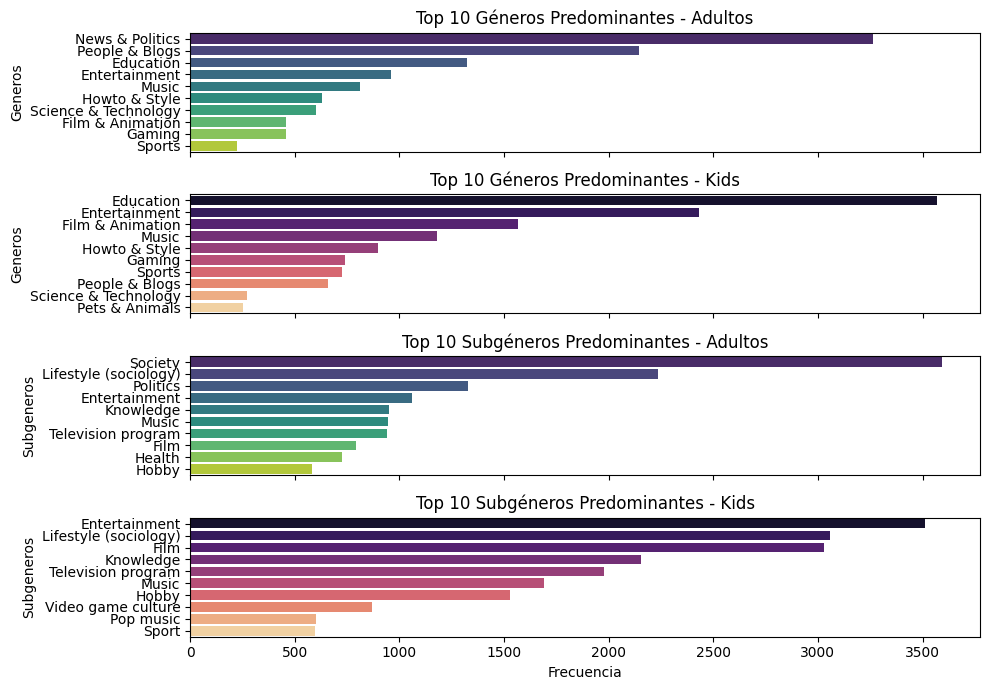

In [7]:
# Configuración
fig, ax = plt.subplots(4, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
utils.graficar_top_generos(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis', "Generos")
utils.graficar_top_generos(df_Kids, 'Top 10 Géneros Predominantes - Kids', ax[1], 'magma', "Generos")
utils.graficar_top_generos(df_Adult, 'Top 10 Subgéneros Predominantes - Adultos', ax[2], 'viridis', "Subgeneros")
utils.graficar_top_generos(df_Kids, 'Top 10 Subgéneros Predominantes - Kids', ax[3], 'magma', "Subgeneros")
plt.tight_layout()
plt.show()

A parte del genero "Education", que predomina en el grupo "kids", el resto de géneros orientados a un publico infantil son todos asociados al entrentenimiento. Mientras que en el grupo "Adultos" encontramos más variedad, incluyendo géneros como "News & Politics", que en el primer grupo que mencionamos no aparece.

En los subgéneros observamos mas o menos lo mismo.

Observamos que los géneros más voluminosos (Education, Entertainment, Film & Animation) están presentes en ambos grupos. Esto genera una ambigüedad por lo que consideramos que la frecuencia de género no es suficiente para clasificar con seguridad.

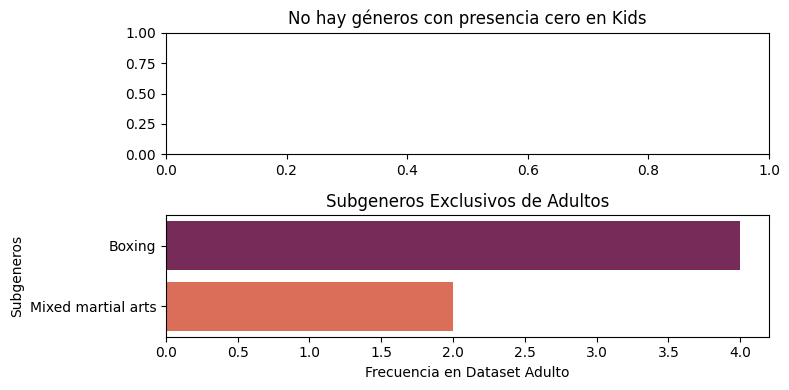

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(8,4))
utils.graficar_generos_ausentes_kids(df_Adult, df_Kids, ax[0], "Generos")
utils.graficar_generos_ausentes_kids(df_Adult, df_Kids, ax[1], "Subgeneros")
plt.tight_layout()
plt.show()

La utilidad de los géneros en este modelo no reside en la frecuencia de los más usados, sino en la certeza de los ausentes, convirtiendo la escasez de datos en ciertas categorías en una herramienta de filtrado de alta precisión. Al cambiar la muestra de datos, ahora no hay géneros ausentes en Kids. Sin embargo en subgeneros podemos apreciar una tendencia a videos relacionados con la violecia como vienen a ser "Boxing" y "Mixed martial arts".

La ausencia total de estos temas en el grupo Kids nos permite establecer una lista de generos "prohibidos". Si el clasificador detecta una de estas etiquetas en un vídeo, lo mejor es que este sea descartado como apto para niños, independientemente de si su vocabulario o duración sugieren lo contrario.


## Densidad de habla (wpm)

In [9]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(utils.calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_Kids['Palabras_Por_Minuto'] = df_Kids.apply(utils.calcular_wpm, axis=1)
df_Kids['Palabras_Por_Minuto'] = round(df_Kids['Palabras_Por_Minuto'], 2)


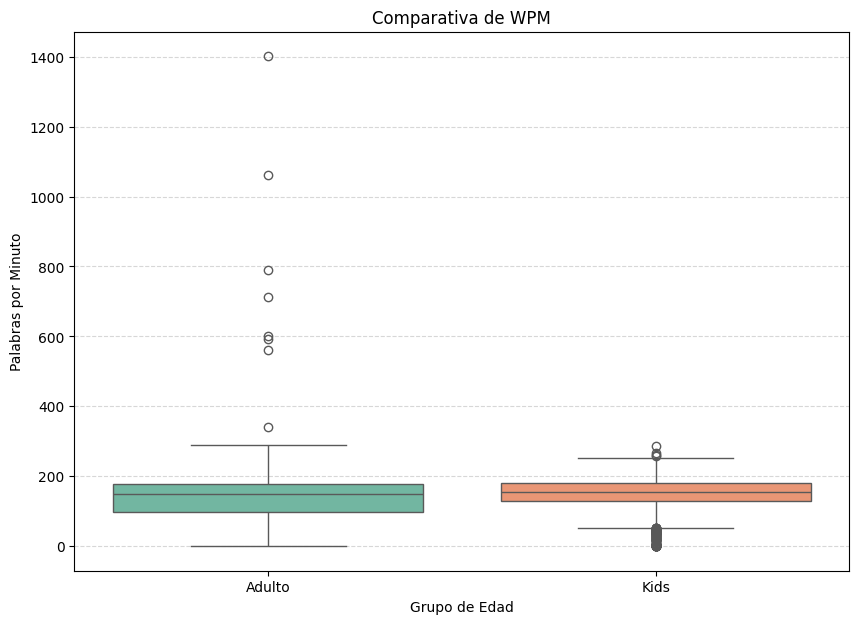

In [10]:
# Filtramos los vídeos sin palabras que no tienen subtitulos
df_wpm_total = pd.concat([
    df_Adult[df_Adult['Palabras_Por_Minuto'] > 0].assign(Grupo='Adulto'),
    df_Kids[df_Kids['Palabras_Por_Minuto'] > 0].assign(Grupo='Kids')
])

#Gráfica
plt.figure(figsize=(10, 7))

sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de WPM')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Sorprendentemente, la mediana de palabras por minuto en el grupo Kids es ligeramente superior a la del grupo Adulto. Esto sugiere que, cuando un vídeo infantil es de carácter narrativo o educativo, mantiene un ritmo verbal constante y dinámico para mantener la atención del menor.

La caja del grupo infantil es notablemente más compacta. Esto indica que el contenido para niños sigue un estándar de producción muy rígido, el ritmo de habla es más uniforme.

El grupo Adulto presenta una caja mucho más amplia y bigotes más largos. Esto refleja la enorme heterogeneidad de su contenido; mientras que en Kids el ritmo es predecible, en adultos conviven géneros con una carga de guion mínima junto a otros de altísima densidad verbal.

Para nuestro clasificador, esto significa que el WPM por sí solo no define si un vídeo es para niños o adultos, sino su variabilidad.

Es importante señalar que la muestra de vídeos infantiles con subtítulos disponibles es considerablemente menor que la de adultos. Esto suguiere que los resultados de WPM en el grupo Kids podrían no ser plenamente representativos.

# Análisis textual

## Título

In [11]:
df_tf_titulo_kids = utils.tfidf_ngrams_titles(df_Kids, "Titulo")
df_tf_titulo_adults = utils.tfidf_ngrams_titles(df_Adult, "Titulo")


In [12]:
common_terms = utils.common_terms(df_tf_titulo_kids, df_tf_titulo_adults, "Titulo")

common_terms.sort_values("Diff", ascending=False).head(20)

,Titulo,Score_kids,Score_adults,Diff
0,kids,264.868213,10.916251,253.951962
1,shorts,116.163461,25.972550,90.190911
3,songs,82.621059,5.467559,77.153500
2,song,84.565376,20.860114,63.705262
10,minecraft,63.700238,2.979256,60.720982
12,cartoon,62.565176,2.196389,60.368787
4,learn,76.812382,16.942034,59.870348
8,en,65.614612,6.845299,58.769313
11,videos,63.019098,5.785737,57.233361
14,draw,61.496445,5.329219,56.167226


Como es de esperar la palabra "Kids" tiene mucho mas peso en los videos infantiles, pero no solo eso si no que es una palabra que destaca con diferencia respecto las demás. 

El término "shorts" ocupa el segundo lugar en relevancia para niños y también tiene un puntaje relativamente alto en adultos. Esto indica que el contenido de formato corto es extremadamente efectivo para captar la atención.
Es de las pocas categorías que mantiene cierto interés en el público adulto, aunque la brecha sigue siendo enorme.

Las categorías relacionadas con audio son fundamentales. "songs" y "song" sumados superan a casi cualquier otra categoría.
Términos específicos como "nursery" tienen un score de adultos casi nulo, lo que demuestra que es contenido puramente funcional para el cuidado o entretenimiento de niños pequeños.

Educación vs. Entretenimiento: Palabras como "learn", "learning" y "draw" muestran que el contenido educativo/aspiracional tiene un peso fuerte, similar al de los "cartoons".

In [13]:
kids_only, adults_only = utils.exclusive_terms(df_tf_titulo_kids, df_tf_titulo_adults, "Titulo")

print(adults_only.head(20))
kids_only.head(20)

            Titulo      Score
7617          iran  59.853341
3484        county  38.829999
15036    type beat  33.705414
2556           ceo  30.496494
8963    march 2026  27.254840
1207          asmr  19.611779
8032        killed  15.516776
5761      forecast  13.751265
12808       senate  13.560389
929           amid  13.340332
7638      iran war  12.252425
1158      arrested  11.161718
9295   middle east  10.938141
12036    residents  10.445063
7677        israel  10.301994
8277     lawmakers  10.090086
13515       speaks   9.285504
3175     committee   9.231662
15625      warning   9.130584
10002         noem   8.958216


,Titulo,Score
13893,rhymes,56.822446
11738,nursery rhymes,50.179098
8983,kids songs,44.706723
1941,blippi,41.957987
17433,videos kids,39.250059
2820,cartoons kids,38.515429
5275,educational,37.817522
11612,niños,33.430115
8722,khan academy,32.945497
12142,para niños,30.573842


La tabla de los adultos refleja una audiencia preocupada por la política.

El término dominante es "iran", junto con "iran war", "middle east" e "israel". 
Esto indica un alto interés por conflictos internacionales actuales.

Los términos "asmr" y "type beat" son las únicas notas de entretenimiento, posiblemente usadas como métodos de relajación frente al resto de noticias estresantes.


En la tabla de niños el contenido es puramente formativo, musical y de entretenimiento.

Términos como "rhymes" y "nursery rhymes" lideran. La música es la herramienta principal de retención para esta audiencia.

Aparecen también nombres específicos que actúan como "Blippi", "Bluey" y "Peppa Pig". Son pilares del entretenimiento infantil actual.

Hay una fuerte presencia de términos educativos como "educational", "khan academy" y "read aloud". Esto sugiere que los padres usan estas plataformas con una intención pedagógica.


Mientras que la tabla de adultos está llena de incertidumbre y conflicto (guerra, arrestos, advertencias), la de niños busca el orden y la repetición (rimas, lecciones, personajes conocidos).

En la tabla de adultos, el lenguaje es técnico y serio ("forecast", "committee", "residents"). En la de niños, el lenguaje es funcional y descriptivo ("videos kids", "kids songs"). Esto demuestra que la búsqueda para niños directa y simple, mientras que para los adultos es específica y circunstancial.



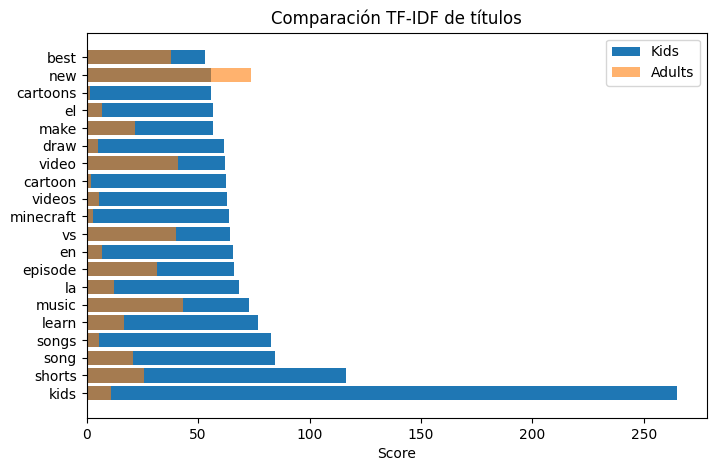

In [14]:
top_terms = common_terms.nlargest(20, "Score_kids")

plt.figure(figsize=(8,5))

plt.barh(top_terms["Titulo"], top_terms["Score_kids"], label="Kids")
plt.barh(top_terms["Titulo"], top_terms["Score_adults"], alpha=0.6, label="Adults")

plt.legend()
plt.title("Comparación TF-IDF de títulos")
plt.xlabel("Score")
plt.show()

In [15]:
topic_model_titulo, df_bertopic_titulo, temas_bertopic_titulo = utils.analizar_bertopic(df, "Titulo")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
df_bertopic_titulo_adults, df_bertopic_titulo_kids = utils.division_edad(df_bertopic_titulo)

print(f'Size of Kids: {len(df_bertopic_titulo_kids)}')
print(f'Size of Adults: {len(df_bertopic_titulo_adults)}')


Size of Kids: 12632
Size of Adults: 11511


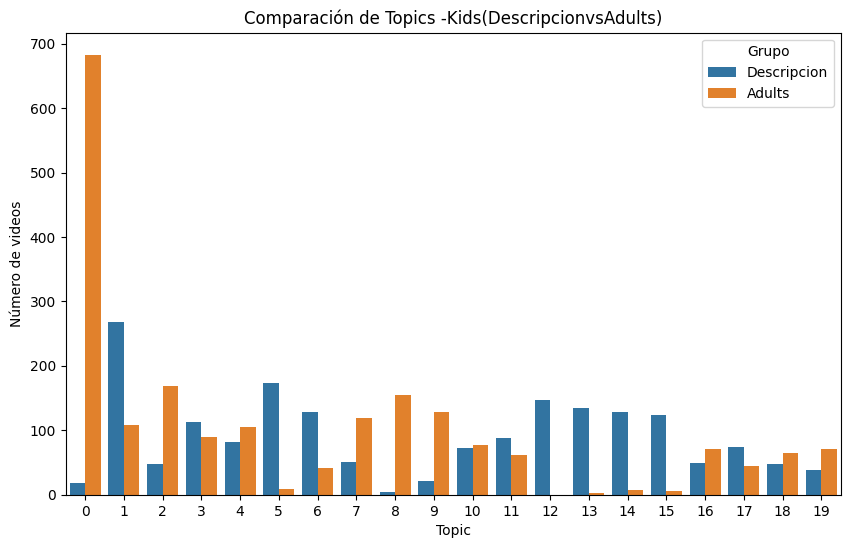

In [ ]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_titulo_adults, df_bertopic_titulo_kids, "Adults", "Kids", "Titulo")
plt.show()

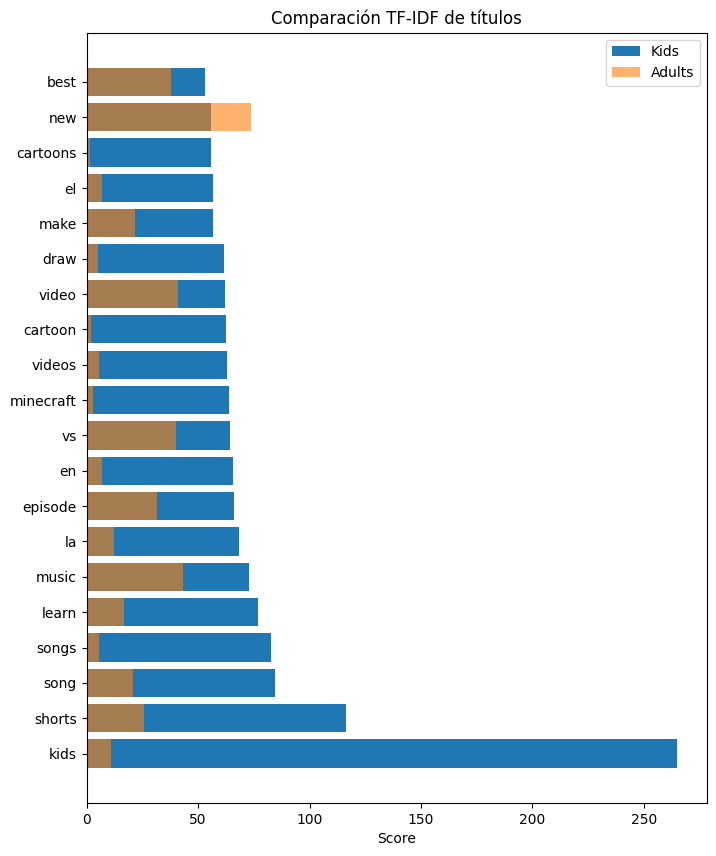

In [18]:
plt.figure(figsize=(8,10))

plt.barh(top_terms["Titulo"], top_terms["Score_kids"], label="Kids")
plt.barh(top_terms["Titulo"], top_terms["Score_adults"], alpha=0.6, label="Adults")

plt.legend()
plt.title("Comparación TF-IDF de títulos")
plt.xlabel("Score")
plt.show()

## Titulo canal


In [19]:
df_tf_titulo_canal_kids = utils.tfidf_ngrams_titles(df_Kids, "Titulo_canal")
df_tf_titulo_canal_adults = utils.tfidf_ngrams_titles(df_Adult, "Titulo_canal")

In [20]:
common_terms = utils.common_terms(df_tf_titulo_canal_kids, df_tf_titulo_canal_adults, "Titulo_canal")

common_terms.sort_values("Diff", ascending=False).head(20)


,Titulo_canal,Score_kids,Score_adults,Diff
0,kids,283.616075,4.729977,278.886098
4,songs,94.110614,1.886435,92.224178
1,official,108.946167,23.807650,85.138516
2,academy,97.653696,13.649852,84.003844
7,khan,84.386135,1.813545,82.572590
6,learn,87.033465,12.785959,74.247506
10,mlb,69.000000,2.000000,67.000000
11,rhymes,67.567374,1.154701,66.412673
13,nursery,64.720461,1.154701,63.565760
14,nursery rhymes,63.692079,1.154701,62.537378


In [21]:
kids_only, adults_only = utils.exclusive_terms(df_tf_titulo_canal_kids, df_tf_titulo_canal_adults, "Titulo_canal")

print(adults_only.head(20))
kids_only.head(20)

      Titulo_canal      Score
1378         drama  82.110511
31              13  44.511321
2605          kvue  37.000000
3998         rvusa  37.000000
3661       podcast  35.743457
22         11alive  35.000000
803          cbs19  32.000000
26         12 news  30.641169
902        chicago  27.748147
4619         today  27.570144
225             ai  27.351041
3359   newschannel  26.618993
5106        whas11  26.000000
2771         local  25.820365
585      bloomberg  24.645506
5290          wpri  24.000000
5081          wfaa  23.560960
504          beats  23.305153
3599  philadelphia  21.949183
2833        ludium  21.000000


,Titulo_canal,Score
2766,khan academy,84.386135
1784,español,73.191442
1456,disney,70.001550
2908,kidz,69.362199
4246,peekaboo kidz,63.976392
4245,peekaboo,63.976392
5915,wildbrain,62.195789
4103,organic chemistry,62.009776
4102,organic,62.009776
4104,organic chemistry tutor,60.365015


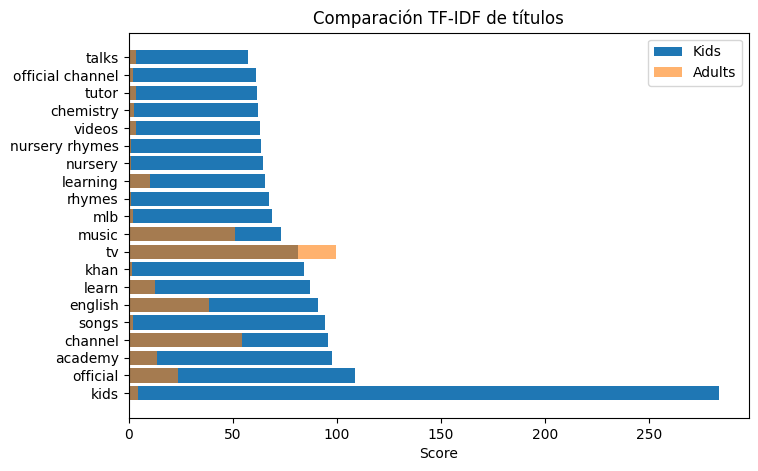

In [ ]:
top_terms = common_terms.nlargest(20, "Score_kids")

plt.figure(figsize=(8,5))

plt.barh(top_terms["Titulo_canal"], top_terms["Score_kids"], label="Kids")
plt.barh(top_terms["Titulo_canal"], top_terms["Score_adults"], alpha=0.6, label="Adults")

plt.legend()
plt.title("Comparación TF-IDF de títulos del canal")
plt.xlabel("Score")
plt.show()

El dominio del azul (Kids) sobre el naranja (Adultos) en esta métrica indica que los canales para niños usan nombres extremadamente repetitivos y predecibles. Nuevamente palabaras como "Kids", "Songs" o "Nursery" son clave para canales infantiles.

Los adultos siguen canales con nombres mucho más variados. Al haber tanta variedad, ninguna palabra específica "sobresale" con fuerza en el modelo, a excepción de términos genéricos como "TV". Es el único término donde los adultos superan significativamente a los niños. Esto sugiere que el público adulto consume mucho contenido de canales que extensionden medios tradicionales.
 Los adultos usan términos como "Music" y "Channel", pero siguen siendo más "característicos" de los canales infantiles.

La barra de "kids" es la más larga con diferencia. Esto confirma que es la etiqueta de identidad más fuerte en toda la plataforma.

In [23]:
topic_model_titulo_canal, df_bertopic_titulo_canal, temas_bertopic_titulo_canal = utils.analizar_bertopic(df, "Titulo_canal")
df_bertopic_titulo_canal_adults, df_bertopic_titulo_canal_kids = utils.division_edad(df_bertopic_titulo_canal)

print(f'Size of Kids: {len(df_bertopic_titulo_canal_kids)}')
print(f'Size of Adults: {len(df_bertopic_titulo_canal_adults)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Size of Kids: 12632
Size of Adults: 11511


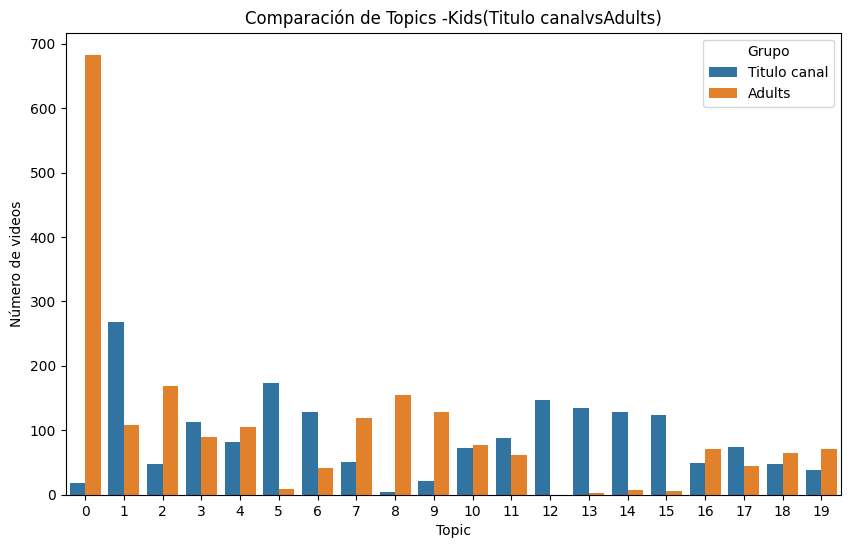

In [ ]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_titulo_canal_adults, df_bertopic_titulo_canal_kids, "Adults", "Kids", "Titulo canal")
plt.show()

## Tags


In [26]:
df_freq_tags_adults = utils.frecuencia_tags(df_Adult)
df_freq_tags_kids = utils.frecuencia_tags(df_Kids)
df_tf_tags_adults = utils.tfidf_tags(df_Adult)
df_tf_tags_kids = utils.tfidf_tags(df_Kids)
#df_freq_tags_adults

In [27]:
common_terms = utils.common_terms(df_freq_tags_kids, df_freq_tags_adults, "Tag")
common_terms.sort_values("Frecuencia_adults", ascending=False)

,Tag,Frecuencia_kids,Frecuencia_adults
0,,1545,2858
1792,news,6,859
55,video,147,355
6078,breaking news,1,149
872,politics,12,144
...,...,...,...
6515,fullframe,1,1
6516,full frame,1,1
6518,respect song,1,1
6519,queen of soul,1,1


In [28]:
kids_only, adults_only = utils.exclusive_terms(df_freq_tags_kids, df_freq_tags_adults, "Tag")
print(adults_only.head(10))
kids_only.head(10)

                Tag  Frecuencia
3        local news         202
117          news ]         180
637         [ local         146
1763            ceo         135
538   chinese drama         115
257          cdrama         112
259    chinesedrama         108
1797        local ]          80
5979     shortdrama          68
2965      live news          64


,Tag,Frecuencia
197,cartoons for kids,566
118,videos for kids,419
186,kids cartoon,354
97,cartoon for kids,293
1508,toddlers,242
506,video for kids,225
173,blippi,212
2155,educational videos for kids,202
1289,youtube kids,201
1375,kids music,194


En la tabla de los adultos aparecen repetidamente el termino "local news", lo que demuestra que los adultos están muy interesados por temas de actualidad. 
El otro termino que aparece es "chinease drama" (o similares). Este término es bastante más especifico, lo que nos hace pensar que puede ser casualidad o que los videos con una temática dramatica tienden a estar mejor etiquetados. 
También aparece la palabra "ceo", lo que refuerza que este dataset de adultos tiene un sesgo hacia contenido de negocios y finanzas.

La tabla del grupo "kids" muestra una frecuencia mucho más alta y concentrada.
Mientras que el tag más frecuente de adultos llega a 202, el de niños llega a 566. Esto significa que el contenido infantil está hiper-etiquetado.
Se usan mucho los tags "cartoons for kids", "kids cartoon", "cartoon for kids", "video for kids", etc. Esto confirma una vez mas que la palabra "kids" predomina en este grupo.


In [29]:
common_terms = utils.common_terms(df_tf_tags_kids, df_tf_tags_adults, "Tag")
common_terms

,Tag,Score_kids,Score_adults,Diff
0,kids,8583.434463,106.289279,8477.145184
1,videos,2812.012202,135.683833,2676.328370
2,songs,2775.774354,152.858809,2622.915545
3,cartoon,2509.360203,73.385209,2435.974994
4,children,1980.207876,34.460065,1945.747811
...,...,...,...,...
11947,క,0.301511,0.195865,0.105646
11948,ప,0.301511,0.195865,0.105646
11949,ভ,0.298464,0.313092,-0.014628
11950,musée,0.292716,0.610149,-0.317433


In [30]:
kids_only, adults_only = utils.exclusive_terms(df_tf_tags_kids, df_tf_tags_adults, "Tag")
print(adults_only.head(10))
kids_only.head(10)

                Tag       Score
5441         cdrama  149.923172
5892   chinesedrama  124.270588
27982    shortdrama  101.313065
30281     talksport   86.642085
7553            ctv   80.988206
22390           ott   75.305375
30381         tarot   67.335022
37806            爱情   61.000000
22260        orchid   58.997560
3843        bitcoin   56.410382


,Tag,Score
3817,blippi,821.545431
15022,infantiles,262.106599
15020,infantil,255.688561
3652,binocs,243.486958
21440,oddbods,186.565931
20585,nastya,183.663292
11537,fixies,181.087220
5430,cbeebies,172.038484
23914,pretend,169.648869
21421,octonauts,168.997224


## Descripción

In [5]:
topic_model_descripcion, df_bertopic_descripcion, temas_bertopic_descripcion = utils.analizar_bertopic(df, "Descripcion")
df_bertopic_descripcion_adults, df_bertopic_descripcion_kids = utils.division_edad(df_bertopic_descripcion)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


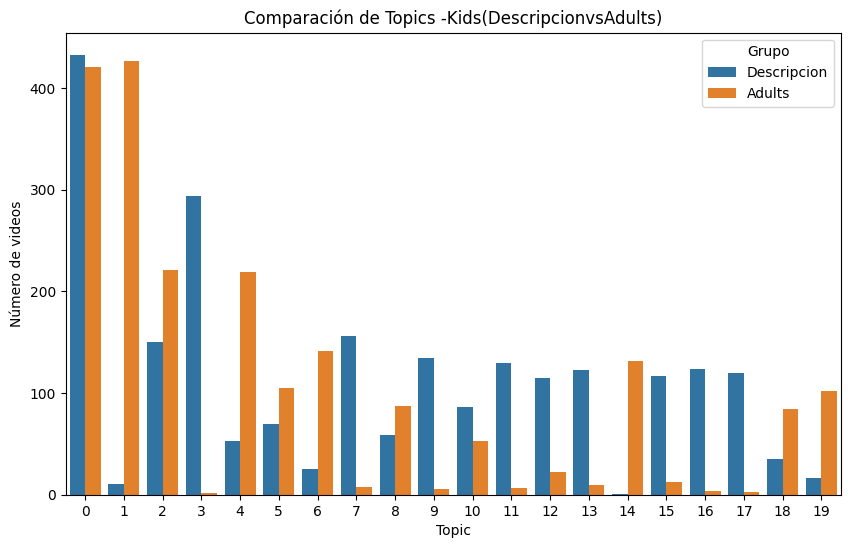

In [ ]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_descripcion_adults, df_bertopic_descripcion_kids, "Adults", "Kids", "Descripcion")
plt.show()

In [8]:
topic_info = topic_model_descripcion.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9837,-1_the_and_of_to,"[the, and, of, to, in, https, for, com, you, is]",[Join us for a fun and engaging short that tea...
1,0,854,0_recipe_recipes_food_ingredients,"[recipe, recipes, food, ingredients, cooking, ...",[Hello Everyone!😄 \nThanks for stopping by.\nT...
2,1,438,1_doo_songs_song_nursery,"[doo, songs, song, nursery, rhymes, kids, oh, ...",[Enjoy watching BabyBus songs and cartoons! 💕 ...
3,2,371,2_filter_mykingdomtv_instagram_com,"[filter, mykingdomtv, instagram, com, https, p...",[Thank you so much for watching! 💞\n💟 ⇉ Make s...
4,3,296,3_iran_fox_news_foxnews,"[iran, fox, news, foxnews, trump, israel, war,...","[Senate Majority Leader John Thune, R-S.D., di..."
5,4,272,4_drawing_draw_rangoli_art,"[drawing, draw, rangoli, art, artforkidshub, d...",[How to Draw a Cute Underwear Easy Step-By-Ste...
6,5,175,5_english_pronunciation_grammar_practice,"[english, pronunciation, grammar, practice, sp...",[In this English grammar lesson you will learn...
7,6,166,6_functions_pl0g_math_formula,"[functions, pl0g, math, formula, function, tut...",[This precalculus video tutorial explains how ...
8,7,164,7_ai_data_agent_agents,"[ai, data, agent, agents, aws, azure, mcp, how...","[Welcome to our latest webinar, where we explo..."
9,8,146,8_pet_thepetcollective_dog_collective,"[pet, thepetcollective, dog, collective, tpc, ...",[This family has a hilarious running joke that...


Topic 1 : Cocina y Recetas. Es el tema más fuerte para adultos. Las palabras clave "recipe", "cooking" e "ingredients" muestran el consumo de tutoriales gastronómicos. En cambio los niños no tienen apenas participación en este "topic".

Topic 2 : Música Infantil. Claramente dominado por el azul (niños).

Topic 4 : Política y Noticias. Se muestra una aparicion predominante por parte de los adultos. Con todo lo observado podemos deducir que lo video enfocados a la politica no son aptos para niños, o simplemente no generan interés en un grupo más joven.

Topic 5 : Arte y Dibujo. "drawing", "artforkidshub". Hay un interés masivo en tutoriales de dibujo para niños.

Topic 6: Inglés y gramática. Las barras están a una altura similar. Tanto niños como adultos consumen este tipo de videos.

Topics 7 : Parecen ser videos enfocados a la educación infantil.

## Subtítulos

In [11]:
topic_model_subtitulos, df_bertopic_subtitulos, temas_bertopic_subtitulos = utils.analizar_bertopic(df, "Subtitulos")
df_bertopic_subtitulos_adults, df_bertopic_subtitulos_kids = utils.division_edad(df_bertopic_subtitulos)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


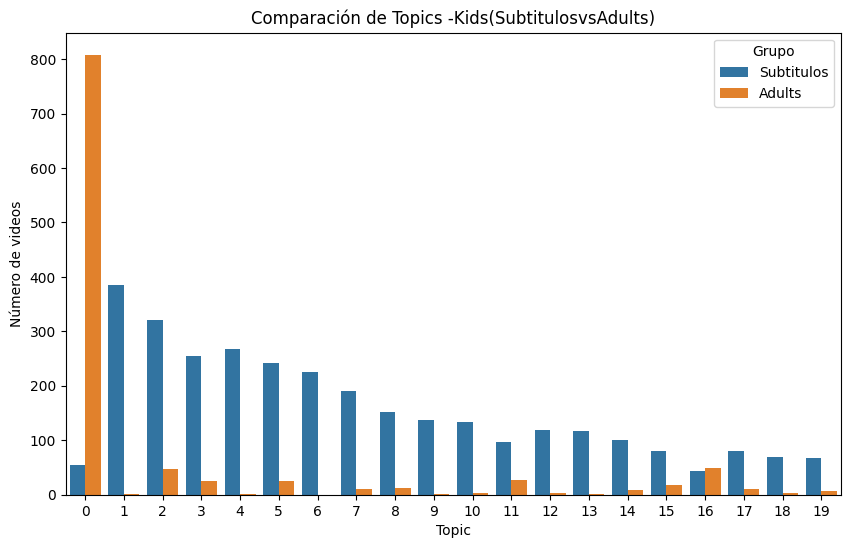

In [12]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_subtitulos_adults, df_bertopic_subtitulos_kids, "Subtitulos", "Adults", "Kids")
plt.show()

In [15]:
topic_info = topic_model_subtitulos.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5805,-1_nbsp_and_that_we,"[nbsp, and, that, we, the, to, gt, of, so, it]",[Kind: captions Language: en Everybody wants t...
1,0,863,0_none___,"[none, , , , , , , , , ]","[None, None, None]"
2,1,386,1_police_county_investigators_case,"[police, county, investigators, case, he, sher...",[Kind: captions Language: en The evidence will...
3,2,368,2_add_nick_gt_butter,"[add, nick, gt, butter, salt, sugar, sauce, li...","[Kind: captions Language: en Well, today's sho..."
4,3,280,3_every_music_light_love,"[every, music, light, love, night, feel, my, t...",[Kind: captions Language: en Golden light on y...
5,4,269,4_me_chen_you_family,"[me, chen, you, family, master, brother, don, ...",[Kind: captions Language: en So refreshing! Ha...
6,5,266,5_game_team_league_ball,"[game, team, league, ball, players, season, he...",[Kind: captions Language: en Hello my YouTuber...
7,6,225,6_iran_iranian_president_trump,"[iran, iranian, president, trump, war, israel,...",[Kind: captions Language: en Good afternoon ev...
8,7,201,7_god_jesus_lord_christ,"[god, jesus, lord, christ, church, pray, holy,...",[Kind: captions Language: en say this with me....
9,8,165,8_your_feel_not_when,"[your, feel, not, when, feels, people, life, b...",[Kind: captions Language: en I want you to ima...
